# Notebook 03: Portfolio Optimization Experiments

**Goal:** Test the optimization layer with real data and understand what the math is doing.

What this notebook covers:
1. Fetch real price data and compute return statistics
2. Run Sharpe ratio optimization — inspect output weights
3. Compare optimized vs equal-weight baseline
4. Plot the efficient frontier
5. Run risk analysis (VaR, drawdown, correlation)
6. Test combined signal (sentiment + optimization blend)
7. End-to-end pipeline: from raw prices to final recommendation weights


In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from dotenv import load_dotenv

load_dotenv('../.env')

# FIX: Create plots directory before any savefig calls
os.makedirs('../data/plots', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
print('Setup complete.')

Setup complete.


---
## Section 1: Load Price Data

In [2]:
# ── 1.1 Fetch prices ──────────────────────────────────────────────────────────
from src.data.stock_fetcher import fetch_stock_data

prices = fetch_stock_data(TICKERS)

# FIX: flatten MultiIndex once at the top so every downstream cell is safe
if isinstance(prices.columns, pd.MultiIndex):
    prices = prices['Close']

# Keep only tickers that were actually returned
prices = prices[[t for t in TICKERS if t in prices.columns]]

print('Price data shape:', prices.shape)
print('Date range:', prices.index[0].date(), '→', prices.index[-1].date())
prices.tail(3)

2026-07-18 13:41:28,743 - INFO - Fetching price data for ['AAPL', 'MSFT', 'GOOGL', 'AMZN'] | period=2y
2026-07-18 13:41:32,028 - INFO - Successfully fetched 501 rows for ['AAPL', 'AMZN', 'GOOGL', 'MSFT']


Price data shape: (501, 4)
Date range: 2024-07-18 → 2026-07-17


Ticker,AAPL,MSFT,GOOGL,AMZN
Date,,,,
2026-07-15,327.50000,395.630005,370.920013,254.960007
2026-07-16,333.26001,401.100006,354.459991,249.889999
2026-07-17,333.73999,393.820007,346.769989,247.229996


In [3]:
# ── 1.2 Compute daily returns and key stats ───────────────────────────────────
returns = prices.pct_change().dropna()
TRADING_DAYS = 252

ann_returns = returns.mean() * TRADING_DAYS
ann_vol     = returns.std()  * np.sqrt(TRADING_DAYS)
sharpe_per_ticker = (ann_returns - 0.05) / ann_vol  # rf = 5%

stats_df = pd.DataFrame({
    'Ann. Return (%)':    (ann_returns * 100).round(2),
    'Ann. Volatility (%)': (ann_vol    * 100).round(2),
    'Sharpe Ratio':        sharpe_per_ticker.round(3)
})

print('Per-Ticker Statistics:')
print(stats_df.to_string())

Per-Ticker Statistics:
        Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio
Ticker                                                    
AAPL              24.49                28.38         0.687
MSFT              -1.37                26.39        -0.241
GOOGL             38.94                31.22         1.087
AMZN              20.33                32.82         0.467


---
## Section 2: Sharpe Ratio Optimization

In [4]:
# ── 2.1 Run the optimizer ─────────────────────────────────────────────────────
from src.optimization.portfolio import PortfolioOptimizer

optimizer = PortfolioOptimizer(prices)
print(optimizer.summary())

[PortfolioOptimizer] Initialized with 4 assets: ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
  Price data points : 501
  Return data points: 500

[PortfolioOptimizer] Per-ticker statistics:
  Ticker     Exp Return   Volatility
  ──────────────────────────────────
  AAPL           24.49%       28.38%
  MSFT           -1.37%       26.39%
  GOOGL          38.94%       31.22%
  AMZN           20.33%       32.82%


In [5]:
# ── 2.2 Get optimized weights ─────────────────────────────────────────────────
opt_result = optimizer.optimize()

# Use only tickers present in the result
result_tickers = opt_result['tickers']

print('\nOptimized Portfolio:')
print(f'{"Ticker":<8} {"Weight":>10} {"Bar"}')
print('─' * 40)
for ticker, weight in opt_result['weights'].items():
    bar = '█' * int(weight * 40)
    print(f'{ticker:<8} {weight*100:>9.1f}% {bar}')

print(f'\nExpected Return : {opt_result["expected_return"]*100:.2f}%')
print(f'Volatility      : {opt_result["volatility"]*100:.2f}%')
print(f'Sharpe Ratio    : {opt_result["sharpe_ratio"]:.4f}')
print(f'Weights sum     : {sum(opt_result["weights"].values()):.6f}')


[PortfolioOptimizer] Running Sharpe ratio optimization...
  Weights sum to  : 1.000000 (✅)
  All non-negative: ✅
  Expected Return : 35.33%
  Volatility      : 27.09%
  Sharpe Ratio    : 1.1196

Optimized Portfolio:
Ticker       Weight Bar
────────────────────────────────────────
AAPL          25.0% █████████
MSFT           0.0% 
GOOGL         75.0% ██████████████████████████████
AMZN           0.0% 

Expected Return : 35.33%
Volatility      : 27.09%
Sharpe Ratio    : 1.1196
Weights sum     : 1.000000


In [6]:
# ── 2.3 Compare with equal weight baseline ────────────────────────────────────
baseline = optimizer.equal_weight_baseline()

# FIX: build the comparison DataFrame safely from dicts (not .T on mixed types)
comparison = pd.DataFrame({
    'Equal Weight (%)': {t: round(v * 100, 1) for t, v in baseline['weights'].items()},
    'Optimized (%)':    {t: round(v * 100, 1) for t, v in opt_result['weights'].items()},
})

print('Weight Comparison:')
print(comparison.to_string())

print()
print(f'{"Metric":<20} {"Equal Weight":>15} {"Optimized":>15} {"Improvement"}')
print('─' * 65)
for metric, b_val, o_val in [
    ('Expected Return', baseline['expected_return'], opt_result['expected_return']),
    ('Volatility',      baseline['volatility'],      opt_result['volatility']),
    ('Sharpe Ratio',    baseline['sharpe_ratio'],     opt_result['sharpe_ratio'])
]:
    diff = o_val - b_val
    sign = '+' if diff > 0 else ''
    print(f'{metric:<20} {b_val*100:>14.2f}% {o_val*100:>14.2f}%  {sign}{diff*100:.2f}%')

Weight Comparison:
       Equal Weight (%)  Optimized (%)
AAPL               25.0           25.0
MSFT               25.0            0.0
GOOGL              25.0           75.0
AMZN               25.0            0.0

Metric                  Equal Weight       Optimized Improvement
─────────────────────────────────────────────────────────────────
Expected Return               20.60%          35.33%  +14.73%
Volatility                    22.83%          27.09%  +4.26%
Sharpe Ratio                  68.32%         111.96%  +43.65%


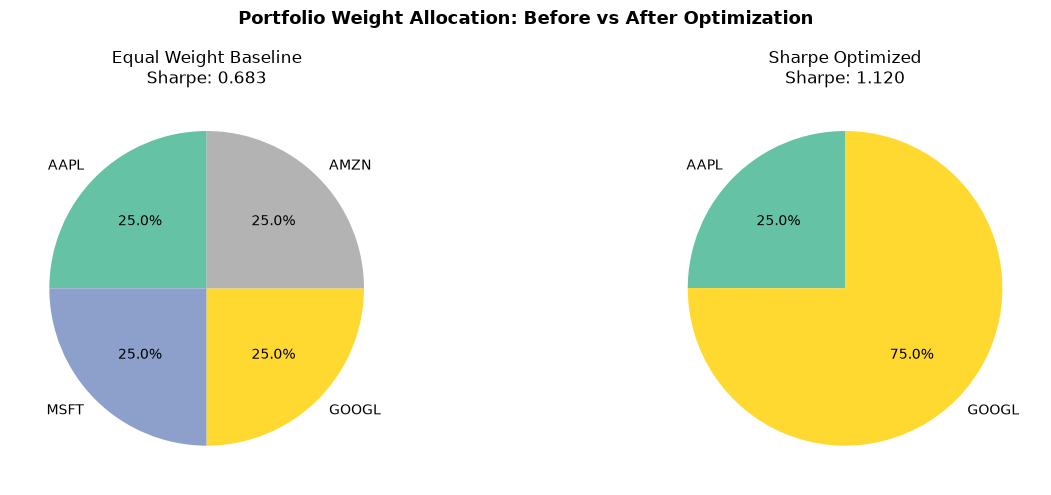

Saved: data/plots/03_weight_comparison.png


In [7]:
# ── 2.4 Visualize weight comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

chart_tickers = result_tickers
colors = plt.cm.Set2(np.linspace(0, 1, len(chart_tickers)))

eq_vals  = [baseline['weights'].get(t, 0)    for t in chart_tickers]
opt_vals = [opt_result['weights'].get(t, 0)  for t in chart_tickers]

# FIX: filter out zero-weight slices so autopct doesn't crash or show '0.0%'
# Equal weight — all shares are equal so no filtering needed
axes[0].pie(
    eq_vals, labels=chart_tickers, autopct='%1.1f%%',
    colors=colors, startangle=90
)
axes[0].set_title(f'Equal Weight Baseline\nSharpe: {baseline["sharpe_ratio"]:.3f}', fontsize=12)

# Optimized — some weights may be zero; keep label blank for those
opt_labels = [t if w > 0.001 else '' for t, w in zip(chart_tickers, opt_vals)]
axes[1].pie(
    [max(w, 0) for w in opt_vals],  # ensure no negatives from float rounding
    labels=opt_labels,
    autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
    colors=colors, startangle=90
)
axes[1].set_title(f'Sharpe Optimized\nSharpe: {opt_result["sharpe_ratio"]:.3f}', fontsize=12)

plt.suptitle('Portfolio Weight Allocation: Before vs After Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/03_weight_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/03_weight_comparison.png')

---
## Section 3: Efficient Frontier

In [8]:
# ── 3.1 Sample random portfolios to build efficient frontier ──────────────────
print('Sampling 3000 random portfolios for efficient frontier...')
frontier_df = optimizer.efficient_frontier(n_points=3000)
print(f'Sampled {len(frontier_df)} portfolios.')
frontier_df.head(3)

Sampling 3000 random portfolios for efficient frontier...
[PortfolioOptimizer] Sampling 3000 random portfolios...
Sampled 3000 portfolios.


,return,volatility,sharpe
0,0.259185,0.250297,0.835748
1,0.216676,0.272093,0.612570
2,0.309488,0.251823,1.030437


Using frontier columns: {'ret': 'return', 'vol': 'volatility', 'sharpe': 'sharpe'}


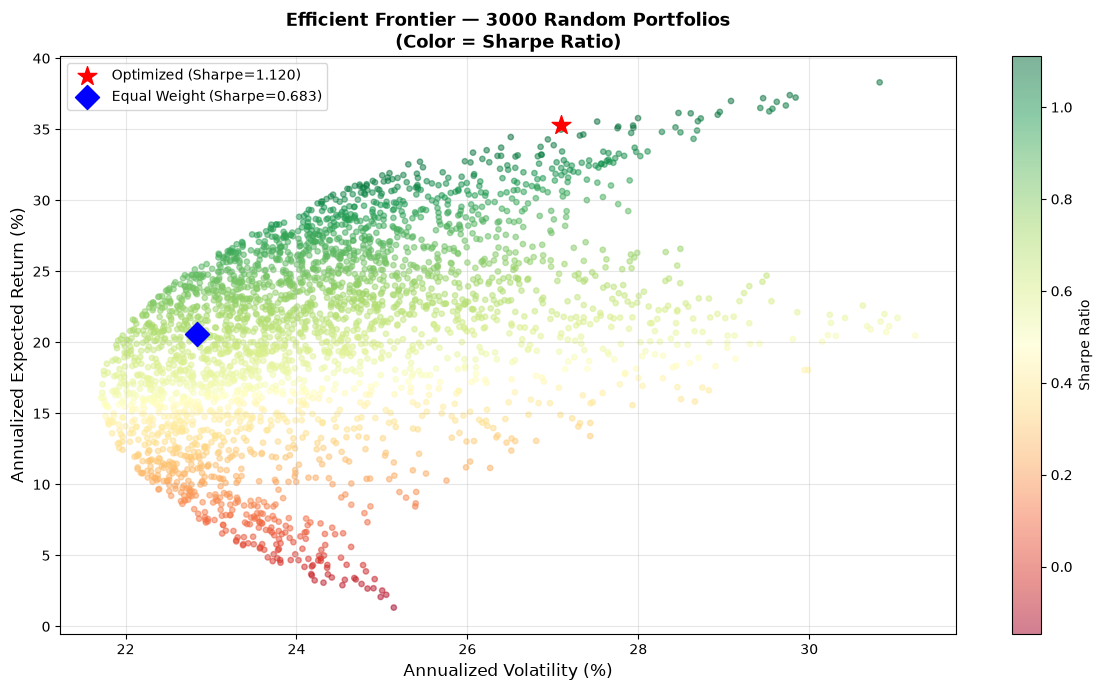

Saved: data/plots/03_efficient_frontier.png


In [9]:
# ── 3.2 Plot efficient frontier ───────────────────────────────────────────────
#
# FIX: efficient_frontier() returns columns named 'return', 'volatility', 'sharpe'
# Verify column names match before plotting; handle either naming convention.
col_map = {}
for candidate in ['return', 'expected_return', 'ret']:
    if candidate in frontier_df.columns:
        col_map['ret'] = candidate
        break
for candidate in ['volatility', 'vol', 'std']:
    if candidate in frontier_df.columns:
        col_map['vol'] = candidate
        break
for candidate in ['sharpe', 'sharpe_ratio']:
    if candidate in frontier_df.columns:
        col_map['sharpe'] = candidate
        break

print('Using frontier columns:', col_map)

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    frontier_df[col_map['vol']] * 100,
    frontier_df[col_map['ret']] * 100,
    c=frontier_df[col_map['sharpe']],
    cmap='RdYlGn',
    alpha=0.5,
    s=15
)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Mark optimized portfolio
ax.scatter(
    opt_result['volatility'] * 100,
    opt_result['expected_return'] * 100,
    color='red', s=200, zorder=10, marker='*',
    label=f'Optimized (Sharpe={opt_result["sharpe_ratio"]:.3f})'
)

# Mark equal weight
ax.scatter(
    baseline['volatility'] * 100,
    baseline['expected_return'] * 100,
    color='blue', s=150, zorder=10, marker='D',
    label=f'Equal Weight (Sharpe={baseline["sharpe_ratio"]:.3f})'
)

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Expected Return (%)', fontsize=12)
ax.set_title(
    'Efficient Frontier — 3000 Random Portfolios\n(Color = Sharpe Ratio)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/plots/03_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/03_efficient_frontier.png')

---
## Section 4: Risk Analysis

In [10]:
# ── 4.1 Full risk report ──────────────────────────────────────────────────────
#
# FIX: RiskAnalyzer must be created BEFORE the VaR / drawdown / correlation
# cells that depend on it.  Moved the instantiation to this cell so the
# object exists for all subsequent cells in this section.
from src.optimization.risk import RiskAnalyzer

risk_analyzer = RiskAnalyzer(prices)
risk_report   = risk_analyzer.full_risk_report(
    weights=opt_result['weights'],
    portfolio_value=100_000
)

[RiskAnalyzer] Initialized with 4 assets.
  Return periods: 500

[RiskAnalyzer] Generating full risk report...
  Portfolio Volatility : 27.09%
  Historical 95% VaR   : With 95% confidence, max 1-day loss = $2,395 (2.40%)
  Historical 99% VaR   : With 99% confidence, max 1-day loss = $4,499 (4.50%)
  Max Drawdown         : -28.68%
  Concentration (HHI)  : HHI=0.625 (High Concentration) | min=0.250
  High Corr Pairs      : None above 0.8 threshold ✅


In [11]:
# ── 4.2 VaR comparison ────────────────────────────────────────────────────────
var_95h = risk_report['value_at_risk']['historical_95']
var_99h = risk_report['value_at_risk']['historical_99']
var_95p = risk_report['value_at_risk']['parametric_95']

print('Value at Risk Summary (Portfolio = $100,000):')
print('─' * 50)
print(f'Historical 95% VaR : ${var_95h["var_usd"]:>10,.0f}  ({var_95h["var_pct"]*100:.2f}%)')
print(f'Historical 99% VaR : ${var_99h["var_usd"]:>10,.0f}  ({var_99h["var_pct"]*100:.2f}%)')
print(f'Parametric 95% VaR : ${var_95p["var_usd"]:>10,.0f}  ({var_95p["var_pct"]*100:.2f}%)')
print()
print('Interpretation:')
print(f'  On any given day, there is a 5% chance of losing more than')
print(f'  ${var_95h["var_usd"]:,.0f} ({abs(var_95h["var_pct"])*100:.2f}% of portfolio).')

Value at Risk Summary (Portfolio = $100,000):
──────────────────────────────────────────────────
Historical 95% VaR : $     2,395  (-2.40%)
Historical 99% VaR : $     4,499  (-4.50%)
Parametric 95% VaR : $     2,664  (-2.66%)

Interpretation:
  On any given day, there is a 5% chance of losing more than
  $2,395 (2.40% of portfolio).


Max Drawdown:
  Portfolio : -28.68%
  AAPL      : -33.36%
  MSFT      : -34.50%
  GOOGL     : -29.81%
  AMZN      : -30.88%


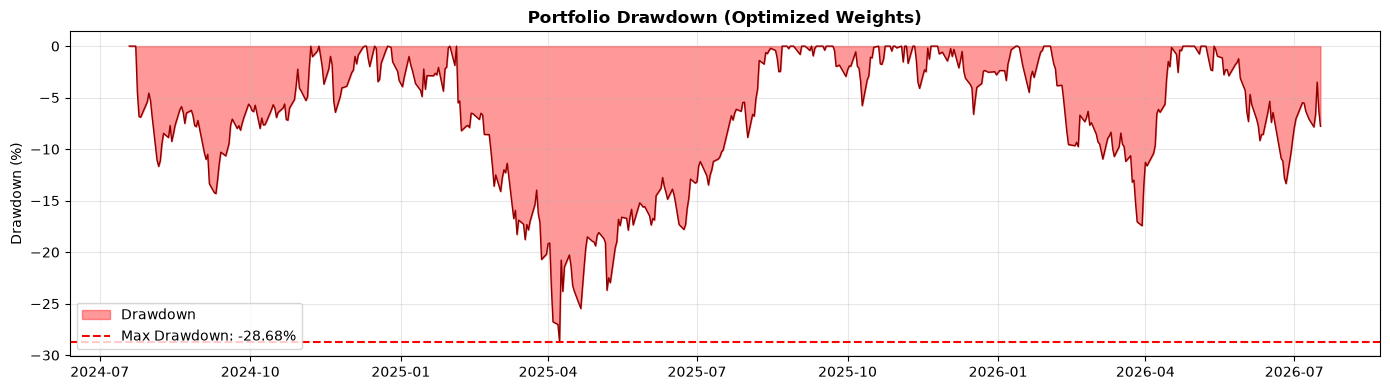

Saved: data/plots/03_drawdown.png


In [12]:
# ── 4.3 Max Drawdown ─────────────────────────────────────────────────────────
mdd_portfolio = risk_report['drawdown']['portfolio']
mdd_tickers   = risk_report['drawdown']['per_ticker']

print('Max Drawdown:')
print(f'  Portfolio : {mdd_portfolio["max_drawdown_pct"]:.2f}%')
for t, mdd in mdd_tickers.items():
    print(f'  {t:<8}  : {mdd:.2f}%')

# Plot drawdown for portfolio
w = np.array([opt_result['weights'].get(t, 0) for t in result_tickers])

# FIX: align weight array with the returns columns that actually exist
aligned_tickers = [t for t in result_tickers if t in returns.columns]
w_aligned       = np.array([opt_result['weights'].get(t, 0) for t in aligned_tickers])
if w_aligned.sum() > 0:
    w_aligned = w_aligned / w_aligned.sum()   # re-normalise after dropping missing tickers

port_returns_series = pd.Series(
    returns[aligned_tickers].values @ w_aligned,
    index=returns.index
)
cumulative   = (1 + port_returns_series).cumprod()
rolling_max  = cumulative.cummax()
drawdown     = (cumulative - rolling_max) / rolling_max * 100

plt.figure(figsize=(14, 4))
plt.fill_between(drawdown.index, drawdown, 0, alpha=0.4, color='red', label='Drawdown')
plt.plot(drawdown.index, drawdown, color='darkred', linewidth=1)
plt.axhline(
    y=mdd_portfolio['max_drawdown_pct'],
    color='red', linestyle='--',
    label=f'Max Drawdown: {mdd_portfolio["max_drawdown_pct"]:.2f}%'
)
plt.ylabel('Drawdown (%)')
plt.title('Portfolio Drawdown (Optimized Weights)', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/plots/03_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/03_drawdown.png')

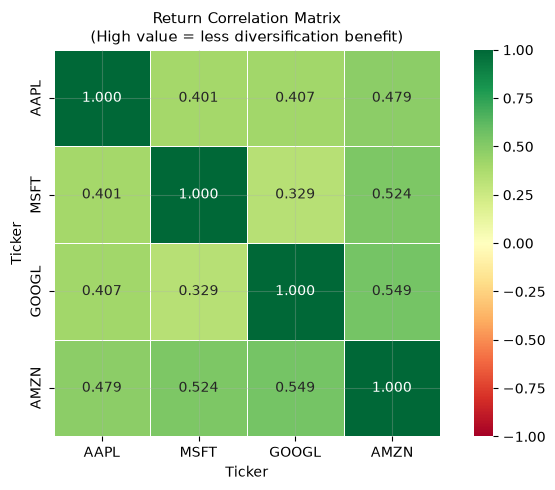

✅ No pairs above 0.8 correlation threshold


In [13]:
# ── 4.4 Correlation heatmap ───────────────────────────────────────────────────
corr_matrix = risk_analyzer.correlation_matrix()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title(
    'Return Correlation Matrix\n(High value = less diversification benefit)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../data/plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr_pairs = risk_report['correlation']['high_correlation_pairs']
if high_corr_pairs:
    print(f'⚠️  High correlation pairs (> 0.8): {high_corr_pairs}')
else:
    print('✅ No pairs above 0.8 correlation threshold')

---
## Section 5: Combined Signal (Sentiment + Optimization)

In [14]:
# ── 5.1 Load sentiment scores (from Notebook 02 or re-compute) ────────────────
from src.data.news_fetcher import fetch_news
from src.models.sentiment import aggregate_sentiment

sentiment_scores = {}
for ticker in result_tickers:
    articles  = fetch_news(ticker)
    headlines = [a.get('title', '') for a in articles if a.get('title')]
    if headlines:
        sentiment_scores[ticker] = aggregate_sentiment(headlines)
    else:
        sentiment_scores[ticker] = 0.0
    print(f'{ticker}: {sentiment_scores[ticker]:+.3f}')

2026-07-18 13:41:41,256 - INFO - Fetching news for AAPL (query: 'AAPL stock')
2026-07-18 13:41:42,033 - INFO - Found 20 articles for AAPL
2026-07-18 13:41:42,037 - INFO - Loading FinBERT model: ProsusAI/finbert
2026-07-18 13:41:42,038 - INFO - First run downloads ~500MB — please wait...
2026-07-18 13:41:42,476 - INFO - HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-18 13:41:42,479 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-18 13:41:42,490 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/tokenizer_config.json "HTTP/1.1 200 OK"
2026-07-18 13:41:42,721 - INFO - HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 40

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

2026-07-18 13:41:44,946 - INFO - FinBERT loaded successfully
2026-07-18 13:41:45,130 - INFO - Analyzed 5/20 articles
2026-07-18 13:41:45,148 - INFO - HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/discussions?p=0 "HTTP/1.1 200 OK"
2026-07-18 13:41:45,303 - INFO - Analyzed 10/20 articles
2026-07-18 13:41:45,403 - INFO - HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/commits/refs%2Fpr%2F29 "HTTP/1.1 200 OK"
2026-07-18 13:41:45,486 - INFO - Analyzed 15/20 articles
2026-07-18 13:41:45,630 - INFO - HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-18 13:41:45,741 - INFO - Analyzed 20/20 articles
2026-07-18 13:41:45,744 - INFO - Fetching news for MSFT (query: 'MSFT stock')
2026-07-18 13:41:45,855 - INFO - HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"


AAPL: -0.008


2026-07-18 13:41:46,304 - INFO - Found 20 articles for MSFT
2026-07-18 13:41:46,502 - INFO - Analyzed 5/20 articles
2026-07-18 13:41:46,662 - INFO - Analyzed 10/20 articles
2026-07-18 13:41:46,812 - INFO - Analyzed 15/20 articles
2026-07-18 13:41:46,955 - INFO - Analyzed 20/20 articles
2026-07-18 13:41:46,956 - INFO - Fetching news for GOOGL (query: 'GOOGL stock')


MSFT: -0.096


2026-07-18 13:41:47,500 - INFO - Found 19 articles for GOOGL
2026-07-18 13:41:47,706 - INFO - Analyzed 5/19 articles
2026-07-18 13:41:47,862 - INFO - Analyzed 10/19 articles
2026-07-18 13:41:48,031 - INFO - Analyzed 15/19 articles
2026-07-18 13:41:48,161 - INFO - Fetching news for AMZN (query: 'AMZN stock')


GOOGL: +0.174


2026-07-18 13:41:48,710 - INFO - Found 20 articles for AMZN
2026-07-18 13:41:48,887 - INFO - Analyzed 5/20 articles
2026-07-18 13:41:49,093 - INFO - Analyzed 10/20 articles
2026-07-18 13:41:49,284 - INFO - Analyzed 15/20 articles
2026-07-18 13:41:49,469 - INFO - Analyzed 20/20 articles


AMZN: +0.206


In [16]:
# ── 5.2 Run combined signal at different alpha values ─────────────────────────
#
# FIX: CombinedSignal.combine() prints verbose output for every call.
# Suppress stdout during the sensitivity_analysis loop so the notebook
# stays readable, then restore it.
import io
import contextlib

from src.optimization.combined_signal import CombinedSignal

combiner = CombinedSignal(opt_result, sentiment_scores)

print('Sensitivity Analysis — How alpha changes final weights:')
with contextlib.redirect_stdout(io.StringIO()):      # suppress per-call output
    sensitivity = combiner.sensitivity_analysis(alphas=[0.0, 0.3, 0.6, 0.8, 1.0])

# Print a clean summary table
alphas = [0.0, 0.3, 0.6, 0.8, 1.0]
header = f'{"Ticker":<8}' + ''.join(f'  α={a:.1f}' for a in alphas)
print(header)
print('─' * len(header))
for ticker in result_tickers:
    row = f'{ticker:<8}'
    for a in alphas:
        w = sensitivity.get(a, {}).get(ticker, 0)
        row += f'  {w*100:5.1f}%'
    print(row)

[CombinedSignal] Initialized with 4 assets.
Sensitivity Analysis — How alpha changes final weights:
Ticker    α=0.0  α=0.3  α=0.6  α=0.8  α=1.0
───────────────────────────────────────────
AAPL       24.0%   24.3%   24.6%   24.8%   25.0%
MSFT        0.0%    0.0%    0.0%    0.0%    0.0%
GOOGL      74.0%   74.3%   74.6%   74.8%   75.0%
AMZN        2.0%    1.4%    0.8%    0.4%    0.0%


In [17]:
# ── 5.3 Use recommended alpha=0.6 and get final weights ──────────────────────
ALPHA = 0.6
combined_result = combiner.combine(alpha=ALPHA)
final_weights   = combined_result['final_weights']

print(f'\nFinal weights at alpha={ALPHA}:')
for ticker, w in final_weights.items():
    change    = combined_result['weight_changes'][ticker]['change']
    direction = combined_result['weight_changes'][ticker]['direction']
    bar       = '█' * int(w * 40)
    print(f'  {ticker}: {w*100:5.1f}% {direction} {change*100:+.1f}%  {bar}')


[CombinedSignal] Combining signals (alpha=0.6)...
  Alpha meaning: 60% quant + 40% sentiment

  Ticker    Sentiment   Opt Weight  Final Weight   Change
  ───────────────────────────────────────────────────────
  AAPL         -0.008        25.0%         24.6%   → -0.4%
  MSFT         -0.096         0.0%          0.0%   → +0.0%
  GOOGL        +0.174        75.0%         74.6%   → -0.4%
  AMZN         +0.206         0.0%          0.8%   ↑ +0.8%

  Final weights sum: 1.000000 (✅)

Final weights at alpha=0.6:
  AAPL:  24.6% → -0.4%  █████████
  MSFT:   0.0% → +0.0%  
  GOOGL:  74.6% → -0.4%  █████████████████████████████
  AMZN:   0.8% ↑ +0.8%  


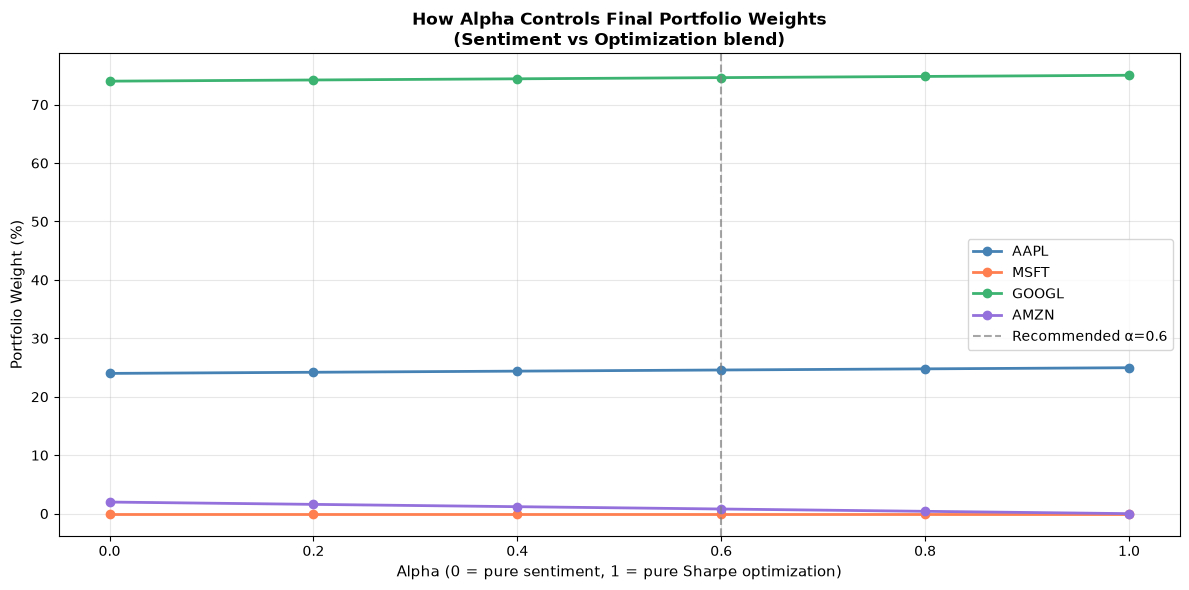

Saved: data/plots/03_alpha_sensitivity.png


In [18]:
# ── 5.4 Visualize weight evolution across alpha values ────────────────────────
#
# FIX: call combine() with redirect_stdout to avoid flooding the output.
alpha_range  = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
all_results  = {}
for a in alpha_range:
    with contextlib.redirect_stdout(io.StringIO()):
        all_results[a] = combiner.combine(alpha=a)['final_weights']

fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'AAPL': 'steelblue', 'MSFT': 'coral', 'GOOGL': 'mediumseagreen', 'AMZN': 'mediumpurple'}

for ticker in result_tickers:
    y_vals = [all_results[a].get(ticker, 0) * 100 for a in alpha_range]
    ax.plot(alpha_range, y_vals, marker='o', linewidth=2, label=ticker,
            color=colors_map.get(ticker))

ax.set_xlabel('Alpha (0 = pure sentiment, 1 = pure Sharpe optimization)', fontsize=11)
ax.set_ylabel('Portfolio Weight (%)', fontsize=11)
ax.set_title(
    'How Alpha Controls Final Portfolio Weights\n(Sentiment vs Optimization blend)',
    fontsize=12, fontweight='bold'
)
ax.axvline(x=0.6, color='gray', linestyle='--', alpha=0.7, label='Recommended α=0.6')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/03_alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/plots/03_alpha_sensitivity.png')

---
## Section 6: End-to-End Pipeline Summary

In [19]:
# ── 6.1 Full pipeline output table ───────────────────────────────────────────
print('=' * 75)
print('FULL PIPELINE SUMMARY — READY FOR API')
print('=' * 75)
print(f'{"Ticker":<8} {"Sentiment":>10} {"Opt Weight":>12} {"Final Weight":>13} {"Change":>8} {"Action"}')
print('─' * 75)

for ticker in result_tickers:
    sent    = sentiment_scores.get(ticker, 0)
    opt_w   = opt_result['weights'].get(ticker, 0)
    final_w = final_weights.get(ticker, 0)
    chg     = combined_result['weight_changes'].get(ticker, {})
    direction = chg.get('direction', '→')
    change_val = chg.get('change', 0)

    if final_w > opt_w + 0.02:
        action = 'BUY MORE'
    elif final_w < opt_w - 0.02:
        action = 'REDUCE'
    else:
        action = 'HOLD'

    print(
        f'{ticker:<8} {sent:>+10.3f} {opt_w*100:>11.1f}% {final_w*100:>12.1f}% '
        f'{direction} {change_val*100:>+5.1f}%  {action}'
    )

print()
print(f'Optimized Sharpe : {opt_result["sharpe_ratio"]:.4f}')
print(f'Alpha used       : {ALPHA}')
print(f'Portfolio VaR 95%: ${risk_report["value_at_risk"]["historical_95"]["var_usd"]:,.0f}')
print(f'Max Drawdown     : {risk_report["drawdown"]["portfolio"]["max_drawdown_pct"]:.2f}%')
print(f'Concentration    : {risk_report["concentration"]["label"]}')
print()
print('✅ Optimization experiments complete.')
print('   Next: FastAPI serves this via /optimize endpoint.')
print('   Then: Streamlit frontend visualizes this output.')

FULL PIPELINE SUMMARY — READY FOR API
Ticker    Sentiment   Opt Weight  Final Weight   Change Action
───────────────────────────────────────────────────────────────────────────
AAPL         -0.008        25.0%         24.6% →  -0.4%  HOLD
MSFT         -0.096         0.0%          0.0% →  +0.0%  HOLD
GOOGL        +0.174        75.0%         74.6% →  -0.4%  HOLD
AMZN         +0.206         0.0%          0.8% ↑  +0.8%  HOLD

Optimized Sharpe : 1.1196
Alpha used       : 0.6
Portfolio VaR 95%: $2,395
Max Drawdown     : -28.68%
Concentration    : High Concentration

✅ Optimization experiments complete.
   Next: FastAPI serves this via /optimize endpoint.
   Then: Streamlit frontend visualizes this output.
